In [1]:
import pandas as pd
import spacy
import numpy as np
from spacy.lang.en import English
from string import punctuation
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.corpus import words, stopwords
from textblob import TextBlob
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

In [2]:
word_list = set(words.words())

In [3]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kamalrajanisrani/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kamalrajanisrani/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Part 1: Preprocessing Pipeline

## Tokenisation

In [4]:
def tokenise(tickets):
    
    nlp = English()
    data = []
    
    for ticket in tickets:
        doc = nlp(ticket)
        sentence = []
        for token in doc:
            sentence.append(token.text)
        data.append(sentence)

    return data

## Case Folding

In [5]:
def lowercase(data):
    
    for sentence in data:
        for i in range(len(sentence)):
            sentence[i] = sentence[i].lower()
    
    return data

## Punctuation Removal

In [6]:
def remove_punctuation(data):

    list_punc = list(punctuation)

    new_data = []

    for sentence in data:
        new_sentence = []
        for word in sentence:
            if word not in list_punc:
                new_sentence.append(word)
        new_data.append(new_sentence)
        
    return new_data

## Hidden Character Removal

In [7]:
def remove_hidden_characters(data):
    
    for sentence in data:
        for i in range(len(sentence)):
            sentence[i] = sentence[i].replace("\n","")
            sentence[i] = sentence[i].replace("\t","")
            sentence[i] = sentence[i].replace("\'", "")

    return data

## Whitespace Removal

In [8]:
def whitespace_remove(data):
    
    for sentence in data:
        for i in range(len(sentence)):
            sentence[i] = sentence[i].strip()

    return data

## Stopword Removal

In [9]:
def remove_stopwords(data):
    
    new_data = []
    stop_words = list(stopwords.words('english'))

    for sentence in data:
        new_sentence = []
        for word in sentence:
            if word not in stop_words:
                new_sentence.append(word)
        new_data.append(new_sentence)

    return new_data

## Stemming

In [10]:
def stem_texts_snowball(data):
    
    stemmer = SnowballStemmer('english')
    return [[stemmer.stem(word) for word in sentence] for sentence in data]

## Bringing it all together

In [11]:
def preprocess(tickets):
    
    data = tokenise(tickets)
    data = lowercase(data)
    data = remove_punctuation(data)
    data = remove_hidden_characters(data)
    data = whitespace_remove(data)
    data = remove_stopwords(data)
    data = stem_texts_snowball(data)
    
    return data

# Part 2: Encoding

## Label Similarity
### Finding out the substring present in ticket description which classifies the label. If the substring isn't found, return the entire sentence.

In [12]:
def label_similarity(data):
    
    for index, sentence in enumerate(data):

        similar_word = None
    
        for word in sentence:
            if word in labels[index]:
                similar_word = word
                break
    
        if similar_word:
            sentence.clear()
            sentence.append(similar_word)

    return data

## Building Vocabulary
### Adding unknown token in the vocabulary to account for any unknown word encountered during inference

In [13]:
def build_vocabulary(data):
    
    vocabulary = {"<UNK>": 0}
    
    for sentence in data:
        for word in sentence:
            if word not in vocabulary:
                vocabulary[word] = len(vocabulary)

    return vocabulary

## Building Dataset

In [14]:
def build_dataset(data, labels, vocabulary):
    
    X = []
    for sentence in data:
        feature_vector = [0] * len(vocabulary)
        for word in sentence:
            feature_vector[vocabulary[word]] = 1
        X.append(feature_vector)

    X = np.array(X)
    encoder = LabelEncoder()
    y = encoder.fit_transform(np.array(labels))
    
    return X, y, encoder

# Part 3: Building a classifier

## Calling all functions - loading raw data, preprocessing, label similarity with sentence and vocabulary building

In [15]:
df = pd.read_csv('cw_data.csv', names=['Ticket Description', 'Classification'])
tickets = df['Ticket Description'].tolist()
labels = df['Classification'].tolist()

data = preprocess(tickets)
data = label_similarity(data)
vocabulary = build_vocabulary(data)
X, y, encoder = build_dataset(data, labels, vocabulary)

## Logistic Regression Classification Model

In [16]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, df.index, test_size=0.3, random_state=42, stratify=y)
lr_clf = LogisticRegression(random_state=0, C=0.8).fit(X_train, y_train)
y_pred = lr_clf.predict(X_test)

print('Logistic Regression Train Accuracy:', round(accuracy_score(y_train, lr_clf.predict(X_train)), 3))
print('Logistic Regression Test Accuracy:', round(accuracy_score(y_test, y_pred), 3))
print('Logistic Regression Precision:', round(precision_score(y_test, y_pred, average='macro'), 3))
print('Logistic Regression Recall:', round(recall_score(y_test, y_pred, average='macro'), 3))
print('Logistic Regression F1 Score:', round(f1_score(y_test, y_pred, average='macro'),3))

Logistic Regression Train Accuracy: 0.986
Logistic Regression Test Accuracy: 0.925
Logistic Regression Precision: 0.945
Logistic Regression Recall: 0.918
Logistic Regression F1 Score: 0.924


# Appendix

## Confusion Matrix of Training Data

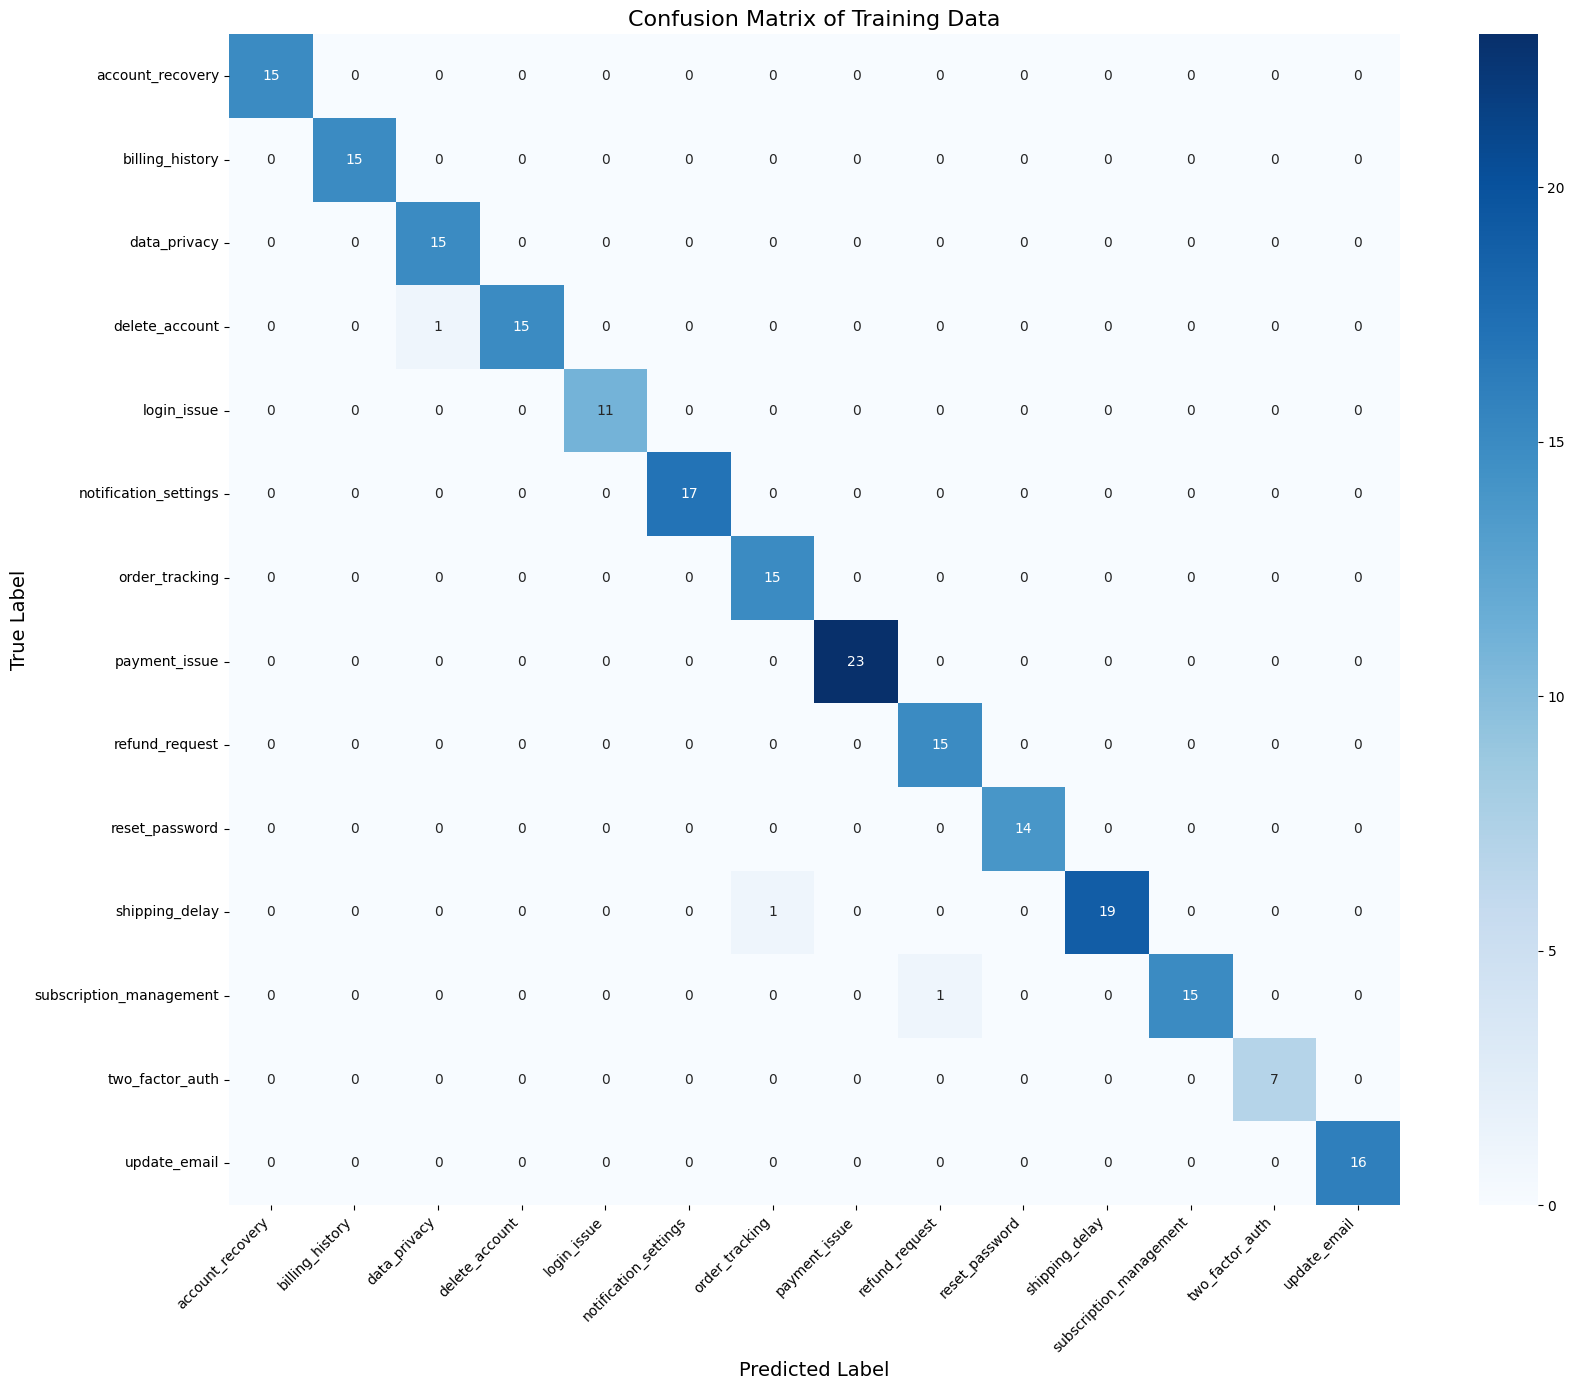

In [17]:
cm = confusion_matrix(y_train, lr_clf.predict(X_train))
class_names = encoder.inverse_transform(lr_clf.classes_)

plt.figure(figsize=(18, 14))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, square=True, cbar=True)

plt.xticks(rotation=45, ha='right')

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix of Training Data", fontsize=16)

plt.tight_layout()
plt.show()

## Confusion Matrix of Test Data

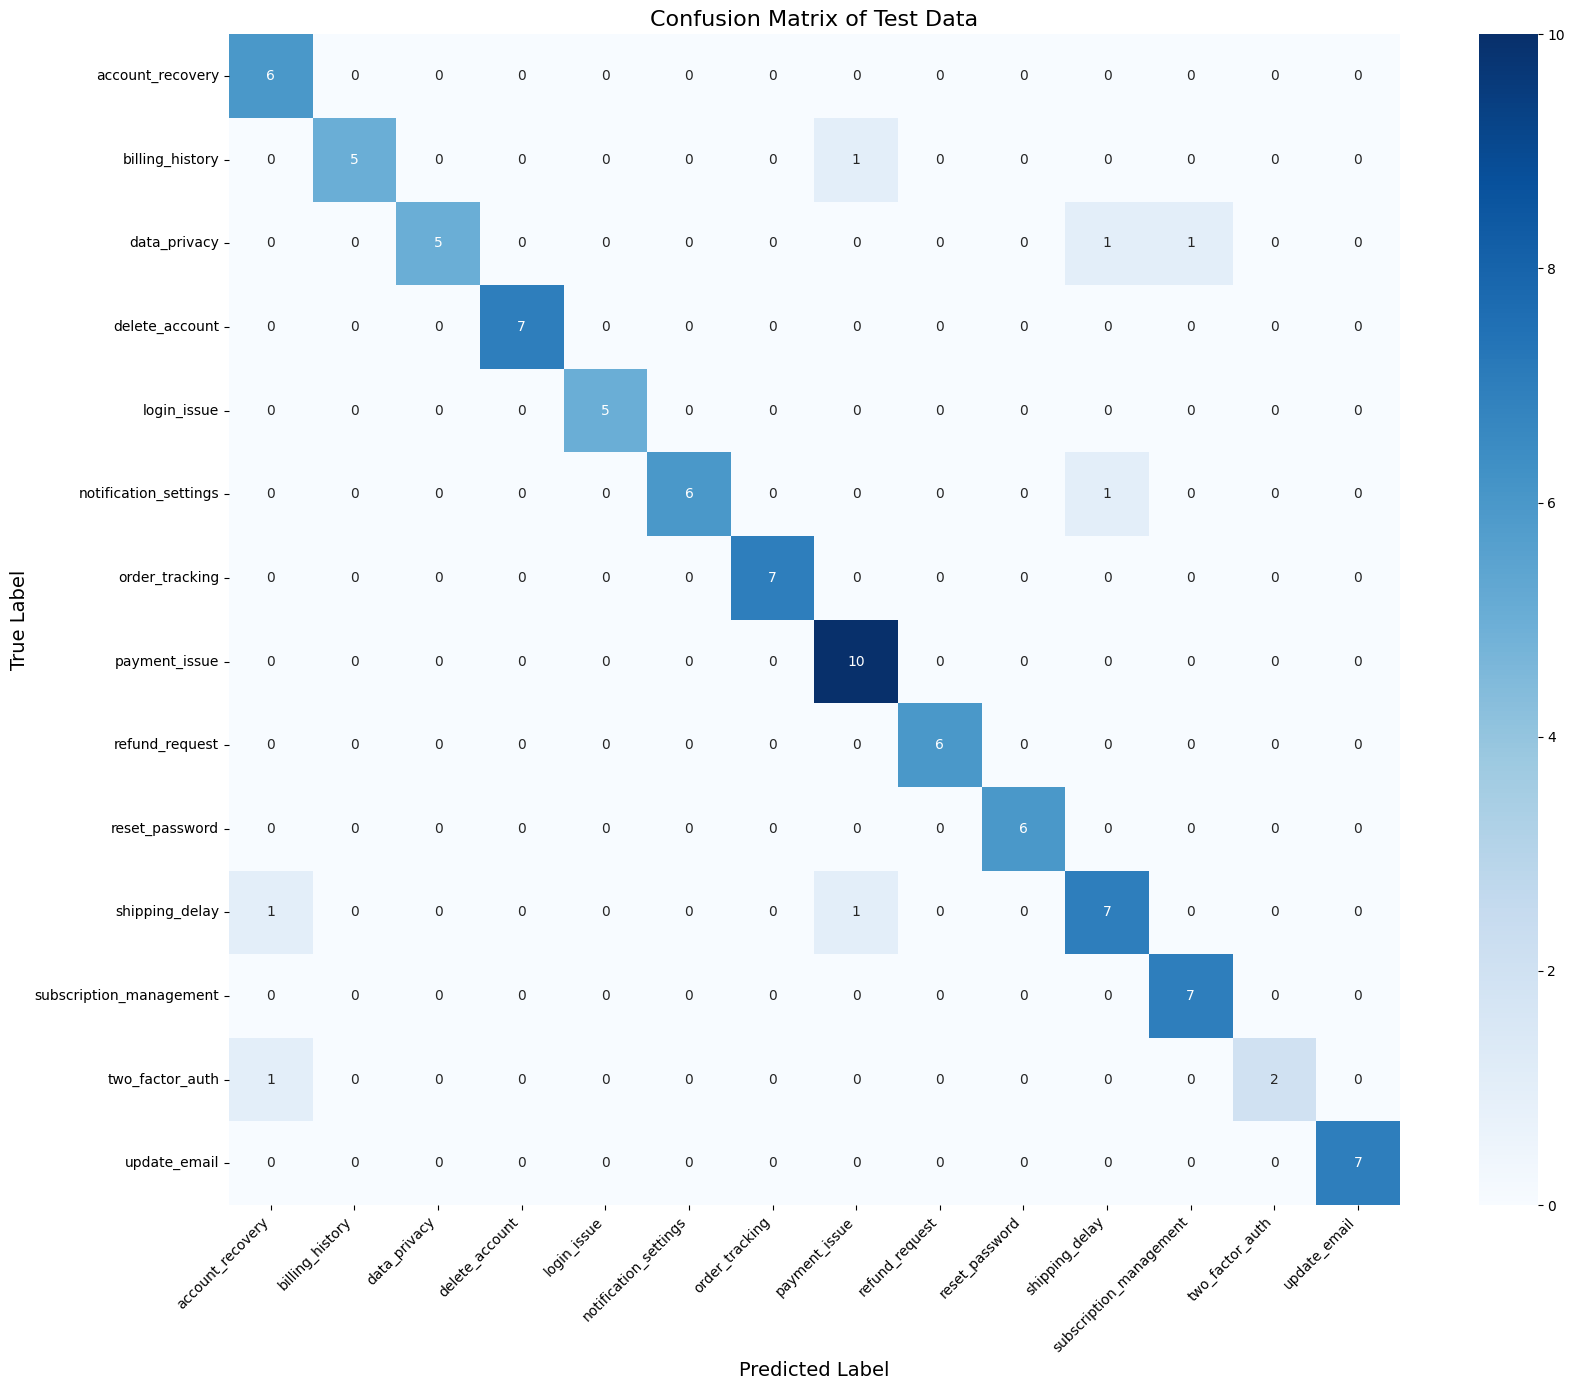

In [18]:
cm = confusion_matrix(y_test, y_pred)
class_names = encoder.inverse_transform(lr_clf.classes_)

plt.figure(figsize=(18, 14))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, square=True, cbar=True)

plt.xticks(rotation=45, ha='right')

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix of Test Data", fontsize=16)

plt.tight_layout()
plt.show()

## Results of key word extraction using label_similarity()

In [19]:
for index, sentence in enumerate(data):
    print(index, sentence, labels[index])

0 ['ship'] shipping_delay
1 ['track'] order_tracking
2 ['email'] update_email
3 ['recov'] account_recovery
4 ['updat'] update_email
5 ['email'] update_email
6 ['recov'] account_recovery
7 ['ship'] shipping_delay
8 ['bill'] billing_history
9 ['data'] data_privacy
10 ['payment'] payment_issue
11 ['track'] order_tracking
12 ['reset'] reset_password
13 ['duplic', 'charg'] billing_history
14 ['subscript'] subscription_management
15 ['bill'] billing_history
16 ['bill'] billing_history
17 ['bill'] billing_history
18 ['delet'] delete_account
19 ['payment'] payment_issue
20 ['restrict', 'process', 'market', 'purpos', 'possibl'] data_privacy
21 ['data'] data_privacy
22 ['track'] order_tracking
23 ['recoveri', 'email', 'receiv', 'help', 'pls'] account_recovery
24 ['refund'] refund_request
25 ['refund'] refund_request
26 ['bill'] billing_history
27 ['data'] data_privacy
28 ['payment'] payment_issue
29 ['delet'] delete_account
30 ['someon', 'els', 'start', 'recoveri', 'acct'] account_recovery
31 ['

## Calculating OOV words in training data

In [20]:
import nltk
from nltk.corpus import words

data = tokenise(tickets)
data = lowercase(data)
data = remove_punctuation(data)
data = remove_hidden_characters(data)
data = whitespace_remove(data)
english_vocab = set(words.words())

total_words_count = 0
non_vocab_words_count = 0

for sentence in data:
    for word in sentence:
        total_words_count += 1
        if word not in english_vocab:
            non_vocab_words_count += 1

percentage = round(non_vocab_words_count * 100 / total_words_count, 2)
print(f"Total words: {total_words_count}")
print(f"OOV words: {non_vocab_words_count}")
print(f"Percentage of OOV words: {percentage}%")

Total words: 2090
OOV words: 512
Percentage of OOV words: 24.5%


## Spelling Mistakes Corrector not being reliable
### 'notifications' converted to 'modifications'

In [21]:
from textblob import TextBlob
sample_sentence = df['Ticket Description'].iloc[229]
print(sample_sentence)

for word in sample_sentence.split():
    modified_word = str(TextBlob(word).correct())
    print(f"{word:15} -> {modified_word}")

stop promotional notifications but keep important ones?
stop            -> stop
promotional     -> promotion
notifications   -> modifications
but             -> but
keep            -> keep
important       -> important
ones?           -> ones?


## Count of number of times labels appear in the dataset

In [22]:
data = tokenise(tickets)
data = lowercase(data)
count = 0
for sentence, label in zip(data, labels):
    found = False
    for word in sentence:
        if word in label and not found:
            count = count + 1
            found = True
print(count)

245


## Analysing misclassified labels for shipping_delay

In [23]:
shipping_delay_label = encoder.transform(['shipping_delay'])[0]

In [24]:
idx = (y_test == shipping_delay_label) & (y_pred != shipping_delay_label)

In [25]:
np.where(idx)

(array([28, 75]),)

In [26]:
for i in np.where(idx)[0]:
    print("DF index:", idx_test[i])
    print("Sentence:", tickets[idx_test[i]])
    print("True:", encoder.inverse_transform([y_test[i]])[0])
    print("Pred:", encoder.inverse_transform([y_pred[i]])[0])
    print()

DF index: 276
Sentence: package lost during shipment — claim process?
True: shipping_delay
Pred: payment_issue

DF index: 232
Sentence: shipment marked delivered but not received!
True: shipping_delay
Pred: account_recovery



## Analysing how much each label contributes to the vocabulary size

In [27]:
vocab = {
    'shipping_delay': {},
    'order_tracking': {},
    'update_email': {},
    'account_recovery': {},
    'billing_history': {},
    'data_privacy': {},
    'payment_issue': {},
    'reset_password': {},
    'subscription_management': {},
    'delete_account': {},
    'refund_request': {},
    'notification_settings': {},
    'login_issue': {},
    'two_factor_auth': {}
}

data = preprocess(tickets)
data = label_similarity(data)

for sentence, label in zip(data, labels):
    for word in sentence:
        if word not in vocab[label]:
            vocab[label][word] = len(vocab[label])

for k, v in sorted(vocab.items(), key=lambda x: len(x[1]), reverse=True):
    print(k, len(v))

shipping_delay 40
account_recovery 31
two_factor_auth 22
data_privacy 18
login_issue 17
billing_history 16
subscription_management 14
payment_issue 13
update_email 12
notification_settings 9
order_tracking 7
delete_account 7
reset_password 2
refund_request 2
